<a href="https://colab.research.google.com/github/mohamadfaisalbashir/Practical-Linear-Algebra/blob/main/11_General_Linear_Models_and_Least_Squares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **General Linear Models and Least Squares**

This notebook covers General Linear Models and Least Squares:
1. General Linear Models
2. The Least Squares Solution
3. Why Least Squares Works: Three Derivations
4. Simple Example: Life Happiness Study
5. Least Squares via QR Decomposition
6. Summary

## **Introduction to Statistical Modeling**

Statistical modeling is the process of creating a simplified mathematical representation of real-world phenomena based on observed data. The key challenge in statistical modeling is that we rarely have complete information; instead, we observe imperfect, noisy data and must infer underlying patterns and relationships. A statistical model provides a framework that relates explanatory variables (called predictors or independent variables) to response variables (called the outcome or dependent variable). The model contains free parameters whose values are determined by fitting the model to observed data. For example, in modeling house prices based on square footage, the relationship might be modeled as Price = β₀ + β₁ × SquareFootage, where β₀ (intercept) and β₁ (slope) are the free parameters to be determined from data. The general linear model (GLM) is one of the most important statistical frameworks and forms the foundation for many practical analyses. What makes it "linear" is that the response variable is modeled as a linear combination of the predictor variables (though the predictors themselves can be nonlinearly transformed). The least squares method, which we'll explore in depth, provides an elegant solution for finding the parameter values that best fit the model to the observed data. Understanding the linear algebra underlying least squares is crucial because it reveals why least squares works, how to implement it efficiently, and how to recognize when the method might encounter numerical difficulties.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg, stats
import warnings
warnings.filterwarnings('ignore')

## **1. General Linear Models**

A general linear model specifies how to combine predictor variables to predict an outcome variable. In matrix form, a GLM is expressed as Xβ = y, where X is the design matrix (containing the predictor variables arranged as columns), β is the vector of regression coefficients (parameters to be determined), and y is the vector of observed outcome values. This notation differs slightly from linear algebra convention (which uses Ax = b) but is standard in statistics. The columns of X correspond to different predictors: the first column is typically all 1s (representing the intercept or constant term), and subsequent columns contain the observed values of each predictor variable. Each row of X corresponds to one observation in the dataset. The key insight is that a system of multiple regression equations can be written compactly in this matrix form, and statistical fitting becomes equivalent to solving a matrix equation. However, there's a crucial difference from algebraic systems: in a GLM, the system is typically overdetermined (more equations than unknowns) and inconsistent (no exact solution exists), because real-world data contains noise and our model is a simplification. This leads to the least squares solution, which finds the coefficients that best fit the data in a precise mathematical sense.

In [2]:
# Made-up data (y=height, w=weight, h=parents_height)
y = np.array([175, 181, 159, 165], dtype=float)
w = np.array([70, 86, 63, 62], dtype=float)
h = np.array([177, 190, 180, 172], dtype=float)

X = np.column_stack([np.ones(4), w, h])

print("Design matrix X:")
print(X)
print("\nOutcome vector y:")
print(y)
print("\nThis represents the system: Xβ = y")
print("where β = [β₀, β₁, β₂]^T")

Design matrix X:
[[  1.  70. 177.]
 [  1.  86. 190.]
 [  1.  63. 180.]
 [  1.  62. 172.]]

Outcome vector y:
[175. 181. 159. 165.]

This represents the system: Xβ = y
where β = [β₀, β₁, β₂]^T


### **2. The Least Squares Solution**

The least squares method finds the coefficients β that minimize the sum of squared errors between the model-predicted values and the observed values. The fundamental equation is: β = (X^T X)^(-1) X^T y. This equation is so important and widely used that it appears throughout statistics, machine learning, and scientific computing with various notations and extensions. The term X^(-1)_left = (X^T X)^(-1) X^T is called the left-inverse or Moore-Penrose pseudoinverse of X (for full-rank X), and it provides a way to "invert" matrices that are not square or not invertible in the traditional sense. The beauty of this formula is that it can be derived in multiple ways: algebraically (from solving normal equations), geometrically (from orthogonal projection), or via calculus (from minimizing the sum of squared errors). Each derivation provides different insight into why least squares works. The least squares solution has the remarkable property that it minimizes the Euclidean distance between the observed data y and the predicted values Xβ. In other words, if you were to choose any other set of coefficients, the predictions would be further from the observations on average. The sum of squared residuals (errors) is minimized, which explains the name "least squares."

In [3]:
# Least squares solution: β = (X^T X)^(-1) X^T y

# Example with made-up data
y = np.array([175, 181, 159, 165], dtype=float)
w = np.array([70, 86, 63, 62], dtype=float)
h = np.array([177, 190, 180, 172], dtype=float)

X = np.column_stack([np.ones(4), w, h])

# Method 1: Using the least squares formula directly
X_left_inv = np.linalg.inv(X.T @ X) @ X.T
beta_formula = X_left_inv @ y

# Method 2: Using numpy's least squares solver (more stable)
beta_numpy, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)

print("Least squares coefficients:")
print(f"β₀ (intercept): {beta_formula[0]:.4f}")
print(f"β₁ (weight coefficient): {beta_formula[1]:.4f}")
print(f"β₂ (parents' height coefficient): {beta_formula[2]:.4f}")

# Compute predictions
y_pred = X @ beta_formula
residuals_manual = y - y_pred

print("\nObserved vs Predicted:")
for i in range(len(y)):
    print(f"Observed: {y[i]:.1f}, Predicted: {y_pred[i]:.1f}, Residual: {residuals_manual[i]:.1f}")

# Compute sum of squared errors
sse = np.sum(residuals_manual**2)
print(f"\nSum of Squared Errors (SSE): {sse:.2f}")

Least squares coefficients:
β₀ (intercept): 276.8560
β₁ (weight coefficient): 1.5165
β₂ (parents' height coefficient): -1.1872

Observed vs Predicted:
Observed: 175.0, Predicted: 172.9, Residual: 2.1
Observed: 181.0, Predicted: 181.7, Residual: -0.7
Observed: 159.0, Predicted: 158.7, Residual: 0.3
Observed: 165.0, Predicted: 166.7, Residual: -1.7

Sum of Squared Errors (SSE): 7.92


### **2.1 Geometric Perspective on Least Squares**

The geometric view of least squares provides profound insight into why the method works and what it means mathematically. From a geometric perspective, the columns of the design matrix X span a subspace of ℝ^m (where m is the number of observations). The least squares problem asks: what point in this subspace (corresponding to some choice of coefficients β) is closest to the observed data point y? The answer is that we want to project y onto the subspace spanned by the columns of X, and the projection vector Xβ is the point in the subspace that is closest to y. The residual vector ε = y - Xβ is orthogonal to this subspace, meaning it is perpendicular to all columns of X. This orthogonality condition provides another way to derive the least squares solution: if the residual is orthogonal to all columns of X, then X^T(y - Xβ) = 0, which gives X^T Xβ = X^T y, and solving for β yields β = (X^T X)^(-1) X^T y. This geometric insight explains why least squares works: we are finding the linear combination of predictors (represented by coefficients in β) that gets as close as possible to the observed data in a perpendicular-distance sense. The geometry also explains important properties: the fitted values are the orthogonal projection of y onto the column space of X, and the residuals are orthogonal to this projection.

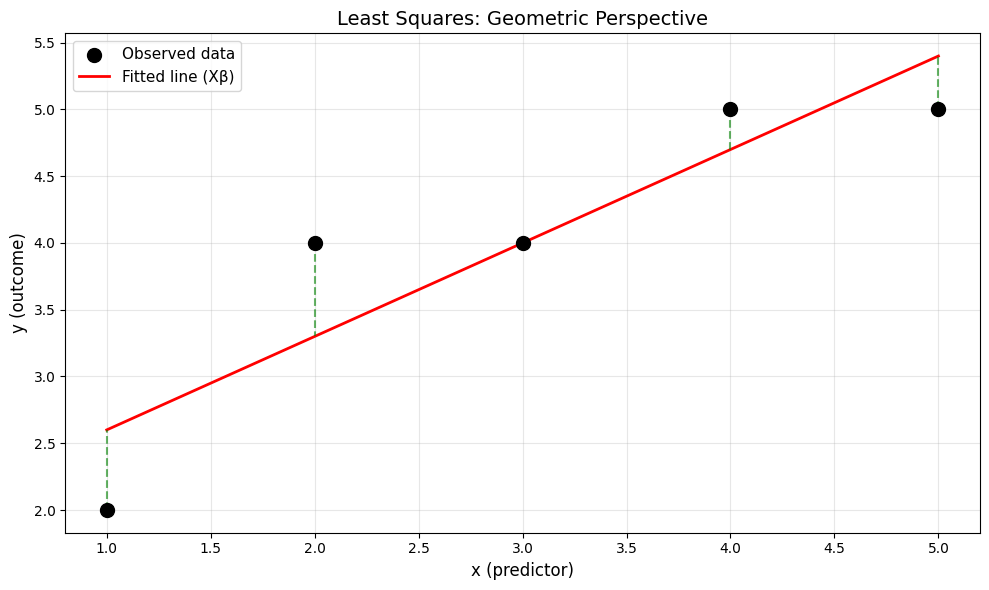

Fitted line: y = 1.9000 + 0.7000*x

Orthogonality check (X^T * residuals should be ~0):
X^T @ residuals = [1.02140518e-14 2.66453526e-14]


In [4]:
# Geometric perspective: projection onto subspace
# Simple example with 1D predictor

# Create simple data
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2, 4, 4, 5, 5], dtype=float)

# Design matrix with intercept
X = np.column_stack([np.ones(5), x])

# Least squares solution
beta = np.linalg.lstsq(X, y, rcond=None)[0]

# Predictions (projection of y onto column space of X)
y_pred = X @ beta

# Residuals (orthogonal to X)
residuals = y - y_pred

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=100, label='Observed data', color='black', zorder=3)
plt.plot(x, y_pred, 'r-', linewidth=2, label='Fitted line (Xβ)')

# Draw residuals (perpendicular to fitted line)
for i in range(len(x)):
    plt.plot([x[i], x[i]], [y[i], y_pred[i]], 'g--', alpha=0.6)

plt.xlabel('x (predictor)', fontsize=12)
plt.ylabel('y (outcome)', fontsize=12)
plt.title('Least Squares: Geometric Perspective', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Fitted line: y = {beta[0]:.4f} + {beta[1]:.4f}*x")
print(f"\nOrthogonality check (X^T * residuals should be ~0):")
print(f"X^T @ residuals = {X.T @ residuals}")

## **3. Why Least Squares Works: Three Derivations**

The least squares solution can be derived in three fundamentally different ways, each providing distinct insight. First, the algebraic approach: we want to minimize the squared error ||Xβ - y||², which is a scalar function of β. Taking the derivative with respect to β and setting it to zero: d/dβ ||Xβ - y||² = 2X^T(Xβ - y) = 0, which yields X^T Xβ = X^T y and solving gives β = (X^T X)^(-1) X^T y. This derivation shows that least squares is the solution to an optimization problem. Second, the geometric approach: the residual vector y - Xβ must be orthogonal to the column space of X (perpendicular to all columns), which means X^T(y - Xβ) = 0. This leads directly to the same formula. The geometric insight is that we're projecting y onto the subspace spanned by X. Third, the normal equations approach: the system Xβ = y is overdetermined and inconsistent, so we premultiply both sides by X^T to get the "normal equations" X^T Xβ = X^T y, which has the same solution as minimizing the squared errors. All three approaches arrive at the identical formula β = (X^T X)^(-1) X^T y, providing multiple ways of understanding why this formula works and what it represents mathematically.

In [5]:
# Demonstrate the three derivations of least squares
np.random.seed(42)

# Create simple data
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2.1, 3.9, 6.2, 7.8, 10.1], dtype=float)

X = np.column_stack([np.ones(5), x])

# Approach 1: Minimize ||Xβ - y||²
# Taking derivative: 2X^T(Xβ - y) = 0
# Solution: X^T Xβ = X^T y
beta_1 = np.linalg.solve(X.T @ X, X.T @ y)

# Approach 2: Orthogonality condition
# Residual orthogonal to column space: X^T * residual = 0
# X^T(y - Xβ) = 0 => X^T y = X^T Xβ => same as above
beta_2 = np.linalg.lstsq(X, y, rcond=None)[0]

# Approach 3: Using pseudoinverse formula explicitly
# β = (X^T X)^(-1) X^T y
X_pseudo_inv = np.linalg.inv(X.T @ X) @ X.T
beta_3 = X_pseudo_inv @ y

print("Three derivations of least squares all give the same result:")
print(f"\nApproach 1 (Calculus): β = {beta_1}")
print(f"Approach 2 (Geometry): β = {beta_2}")
print(f"Approach 3 (Pseudoinverse): β = {beta_3}")

print(f"\nAll approaches agree: y = {beta_1[0]:.4f} + {beta_1[1]:.4f}*x")

# Show that residuals are orthogonal to X
y_pred = X @ beta_1
residuals = y - y_pred
orthogonality = X.T @ residuals
print(f"\nOrthogonality check: X^T @ residuals = {orthogonality}")
print(f"(Should be very close to zero)")

Three derivations of least squares all give the same result:

Approach 1 (Calculus): β = [0.05 1.99]
Approach 2 (Geometry): β = [0.05 1.99]
Approach 3 (Pseudoinverse): β = [0.05 1.99]

All approaches agree: y = 0.0500 + 1.9900*x

Orthogonality check: X^T @ residuals = [-4.44089210e-16  1.50990331e-14]
(Should be very close to zero)


## **4. Simple Example: Life Happiness Study**

Let's apply least squares to a simple real-world style problem. Imagine a fake study surveying students about how many online courses they've taken and their self-reported life happiness. The data is completely made up for this example, but the analysis is illustrative of how least squares works in practice. We have two variables: the number of courses (predictor) and life happiness (outcome). We'll fit a simple linear regression model of the form: happiness = β₀ + β₁ × courses. First, we'll fit the model without an intercept to see why the intercept matters. Then we'll fit the model with an intercept and see how much the fit improves. This example will illustrate the importance of choosing the right model specification and how model fitting can be implemented in practice.

Model 1: No intercept (y = β*x)
Coefficient: 5.7718
Sum of Squared Errors: 555.14

Model 2: With intercept (y = β₀ + β₁*x)
Intercept (β₀): 7.9601
Slope (β₁): 4.9727
Sum of Squared Errors: 267.49


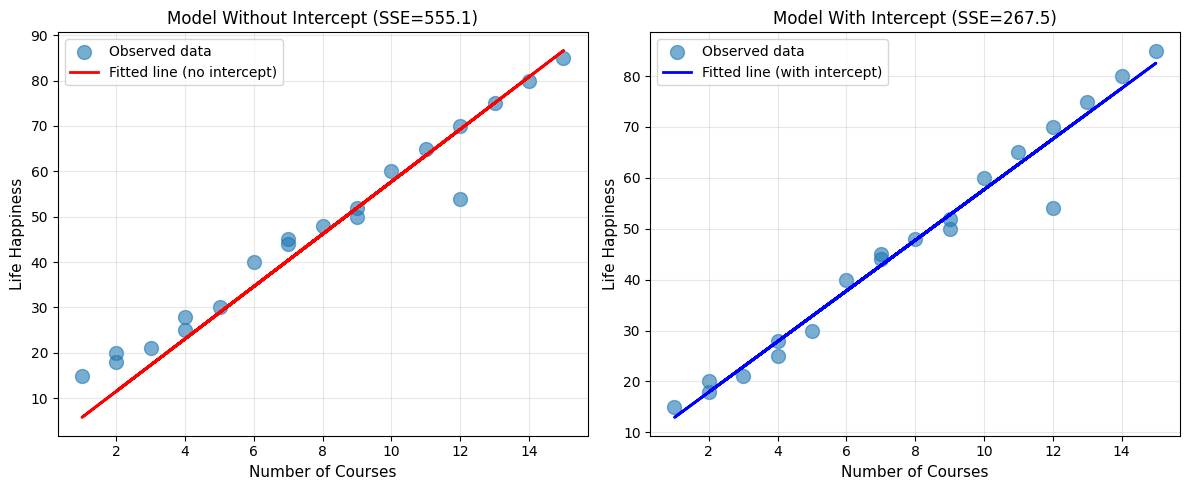


Improvement from adding intercept: 51.8% reduction in SSE


In [6]:
# Fake data: number of courses vs life happiness
courses = np.array([4, 12, 3, 14, 7, 9, 2, 15, 1, 10,
                   5, 13, 6, 11, 8, 4, 9, 2, 12, 7], dtype=float)
happiness = np.array([25, 54, 21, 80, 45, 50, 18, 85, 15, 60,
                    30, 75, 40, 65, 48, 28, 52, 20, 70, 44], dtype=float)

# Model 1: Without intercept (y = β*x, forced through origin)
X_no_intercept = courses.reshape(-1, 1)
beta_no_intercept = np.linalg.lstsq(X_no_intercept, happiness, rcond=None)[0]
y_pred_no_int = X_no_intercept @ beta_no_intercept
sse_no_int = np.sum((happiness - y_pred_no_int)**2)

# Model 2: With intercept (y = β₀ + β₁*x)
X_with_intercept = np.column_stack([np.ones(len(courses)), courses])
beta_with_intercept = np.linalg.lstsq(X_with_intercept, happiness, rcond=None)[0]
y_pred_with_int = X_with_intercept @ beta_with_intercept
sse_with_int = np.sum((happiness - y_pred_with_int)**2)

print("Model 1: No intercept (y = β*x)")
print(f"Coefficient: {beta_no_intercept[0]:.4f}")
print(f"Sum of Squared Errors: {sse_no_int:.2f}")

print("\nModel 2: With intercept (y = β₀ + β₁*x)")
print(f"Intercept (β₀): {beta_with_intercept[0]:.4f}")
print(f"Slope (β₁): {beta_with_intercept[1]:.4f}")
print(f"Sum of Squared Errors: {sse_with_int:.2f}")

# Visualize both models
plt.figure(figsize=(12, 5))

# Plot 1: Without intercept
plt.subplot(1, 2, 1)
plt.scatter(courses, happiness, s=100, alpha=0.6, label='Observed data')
plt.plot(courses, y_pred_no_int, 'r-', linewidth=2, label='Fitted line (no intercept)')
plt.xlabel('Number of Courses', fontsize=11)
plt.ylabel('Life Happiness', fontsize=11)
plt.title(f'Model Without Intercept (SSE={sse_no_int:.1f})', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Plot 2: With intercept
plt.subplot(1, 2, 2)
plt.scatter(courses, happiness, s=100, alpha=0.6, label='Observed data')
plt.plot(courses, y_pred_with_int, 'b-', linewidth=2, label='Fitted line (with intercept)')
plt.xlabel('Number of Courses', fontsize=11)
plt.ylabel('Life Happiness', fontsize=11)
plt.title(f'Model With Intercept (SSE={sse_with_int:.1f})', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nImprovement from adding intercept: {(sse_no_int - sse_with_int)/sse_no_int * 100:.1f}% reduction in SSE")

## **5. Least Squares via QR Decomposition**

While the formula β = (X^T X)^(-1) X^T y is conceptually correct, explicitly computing (X^T X)^(-1) can introduce numerical instability because it involves squaring the condition number of X through the computation of X^T X. A more numerically stable approach uses QR decomposition. From A = QR (using X = QR), we have: Xβ = QRβ = y, so Rβ = Q^T y, and thus β = R^(-1) Q^T y. The key advantages are: (1) Q is computed stably using Householder reflections, (2) R is upper-triangular, so R^(-1) can be computed via back-substitution (highly stable), and (3) we avoid the explicit computation of X^T X, which can amplify numerical errors. For tall matrices (more observations than predictors), Q is tall but with only n columns (in economy mode), and R is a small square upper-triangular matrix. The rows N+1 through M of the tall R are all zeros and don't contribute to the solution. This QR approach is generally what modern numerical software uses internally for solving least squares problems, even though the direct formula might be easier to implement for small problems with well-conditioned data.

In [7]:
# Example data
courses = np.array([1, 2, 3, 4, 5])
happiness = np.array([2, 4, 5, 4, 5])

# Design matrix
X = np.column_stack([np.ones(len(courses)), courses])
y = happiness

# Method 1: Direct least squares formula
beta_direct = np.linalg.lstsq(X, y, rcond=None)[0]

# Method 2: Using QR decomposition
Q, R = linalg.qr(X, mode='economic')

beta_qr = linalg.solve_triangular(R, Q.T @ y)

# Method 3: Explicit formula with QR
beta_qr_explicit = np.linalg.inv(R) @ Q.T @ y

print("Least Squares Solutions:")

print(f"\nDirect (lstsq): β₀={beta_direct[0]:.4f}, β₁={beta_direct[1]:.4f}")
print(f"QR (solve_triangular): β₀={beta_qr[0]:.4f}, β₁={beta_qr[1]:.4f}")
print(f"QR (explicit inverse): β₀={beta_qr_explicit[0]:.4f}, β₁={beta_qr_explicit[1]:.4f}")

# Verify they're the same
print(f"\nDifference (direct vs QR solve): {np.linalg.norm(beta_direct - beta_qr):.2e}")
print(f"Difference (direct vs QR explicit): {np.linalg.norm(beta_direct - beta_qr_explicit):.2e}")

# Show shape of QR decomposition for tall matrix
print(f"\nMatrix dimensions:")
print(f"X: {X.shape}")
print(f"Q (economic mode): {Q.shape}")
print(f"R: {R.shape}")

Least Squares Solutions:

Direct (lstsq): β₀=2.2000, β₁=0.6000
QR (solve_triangular): β₀=2.2000, β₁=0.6000
QR (explicit inverse): β₀=2.2000, β₁=0.6000

Difference (direct vs QR solve): 1.37e-15
Difference (direct vs QR explicit): 1.37e-15

Matrix dimensions:
X: (5, 2)
Q (economic mode): (5, 2)
R: (2, 2)


## **6. Summary**

This chapter has explored the deep connection between linear algebra and statistical modeling through the lens of least squares regression. A general linear model formulates the relationship between predictors and outcomes as a matrix equation Xβ = y, where the design matrix X contains the predictors arranged as columns and each row represents one observation. The least squares method finds the coefficients β that minimize the sum of squared residuals (errors), and this solution can be expressed as β = (X^T X)^(-1) X^T y. This elegantly simple formula can be derived in multiple ways: algebraically from optimization calculus, geometrically from orthogonal projection, and algebraically from normal equations. Each derivation provides distinct insight: the calculus derivation emphasizes that least squares is an optimization method, the geometric derivation reveals that we're projecting the data onto the subspace spanned by the predictors, and the normal equations derivation connects to the classical approach of solving systems of equations. The geometric perspective is particularly illuminating: the least squares solution finds the point in the subspace spanned by X's columns that is closest to the observed data point y, with the residual vector being orthogonal to this subspace. From a computational perspective, the direct formula β = (X^T X)^(-1) X^T y can be numerically unstable due to squaring the condition number through X^T X, so modern implementations use QR decomposition: β = R^(-1) Q^T y, where R is upper-triangular and can be inverted stably via back-substitution. Understanding least squares from these multiple perspectives is essential for data science professionals, as nearly all statistical methods and machine learning algorithms are ultimately built on the foundation of least squares fitting or extensions thereof. The elegant simplicity of the least squares formula masks a deep mathematical structure that connects optimization, linear algebra, geometry, and statistics.